In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Slope (beta_1): -0.1082
Intercept (beta_0): 2.4186


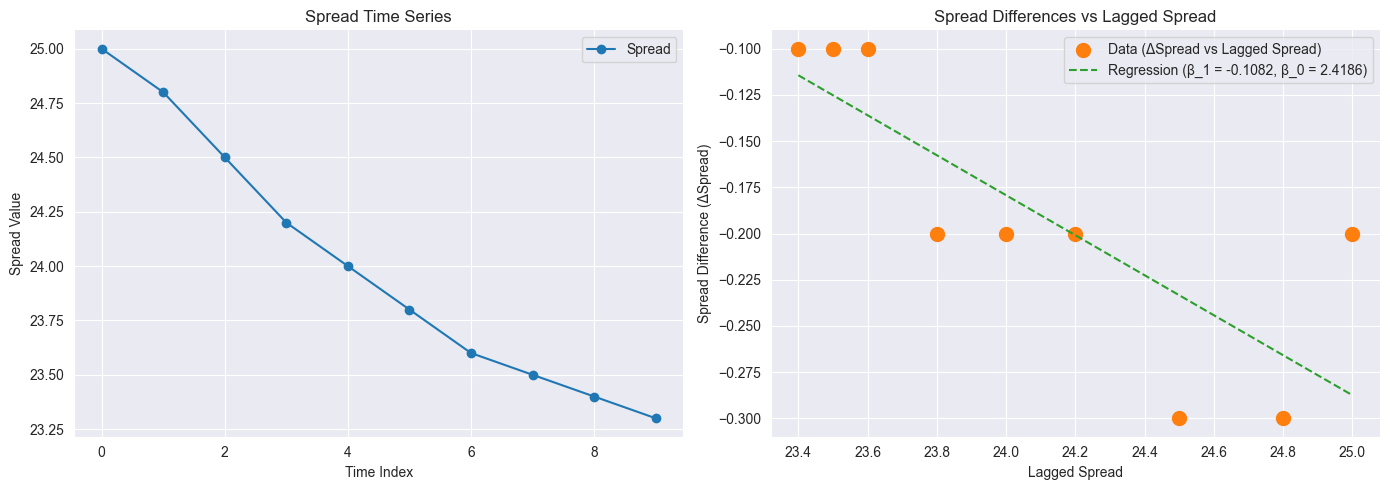

In [ ]:
# Set Seaborn style
sns.set_style('darkgrid')

# Data

spread = pd.Series([25.0, 24.8, 24.5, 24.2, 24.0, 23.8, 23.6, 23.5, 23.4, 23.3])
X = spread.shift().iloc[1:].to_frame().assign(const=1)
y = spread.diff().iloc[1:]

# Full regression
beta_full = np.linalg.inv(X.T @ X) @ X.T @ y
beta_1 = beta_full[0]  # Slope
beta_0 = beta_full[1]  # Intercept
print(f"Slope (beta_1): {beta_1:.4f}")
print(f"Intercept (beta_0): {beta_0:.4f}")

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Time series of the spread
ax1.plot(spread.index, spread.values, marker='o', linestyle='-', color='#1f77b4', label='Spread')
ax1.set_title('Spread Time Series', fontsize=12)
ax1.set_xlabel('Time Index', fontsize=10)
ax1.set_ylabel('Spread Value', fontsize=10)
ax1.legend()
ax1.grid(True)

# Plot 2: Scatter plot with corrected regression line
lagged_spread = X.iloc[:, 0]
ax2.scatter(lagged_spread, y, color='#ff7f0e', label='Data (ΔSpread vs Lagged Spread)', s=100)
x_range = np.linspace(lagged_spread.min(), lagged_spread.max(), 100)
y_fit = beta_1 * x_range + beta_0  # Include intercept
ax2.plot(x_range, y_fit, color='#2ca02c', linestyle='--', label=f'Regression (β_1 = {beta_1:.4f}, β_0 = {beta_0:.4f})')
ax2.set_title('Spread Differences vs Lagged Spread', fontsize=12)
ax2.set_xlabel('Lagged Spread', fontsize=10)
ax2.set_ylabel('Spread Difference (ΔSpread)', fontsize=10)
ax2.legend()
ax2.grid(True)

# Adjust layout
sns.despine()
plt.tight_layout()
plt.show()

Slope (beta_1): -0.0688
Intercept (beta_0): 0.0019


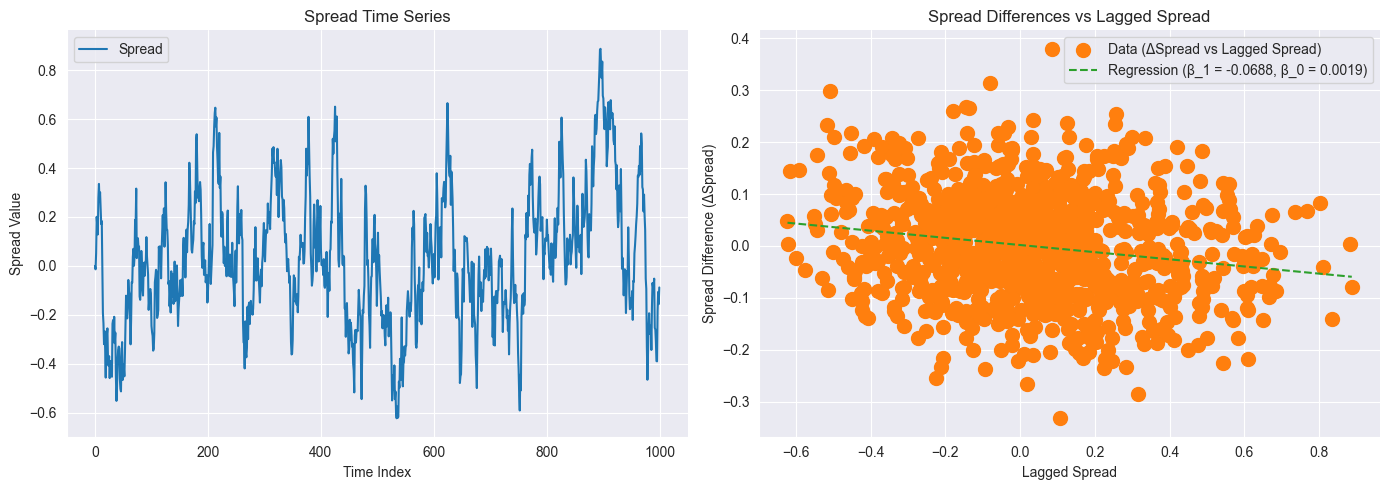

In [16]:
np.random.seed(42)
n = 1000
ar_coef = 0.9307  # φ = 1 - ln(2)/10 ≈ 0.9307 for half-life ~10 days
errors = np.random.normal(0, 0.1, n)
spread = np.zeros(n)
spread[0] = 0
for i in range(1, n):
    spread[i] = ar_coef * spread[i-1] + errors[i]  # AR(1) process
spread_series = pd.Series(spread)


X = spread_series.shift().iloc[1:].to_frame().assign(const=1)
y = spread_series.diff().iloc[1:]

# Full regression
beta_full = np.linalg.inv(X.T @ X) @ X.T @ y
beta_1 = beta_full[0]  # Slope
beta_0 = beta_full[1]  # Intercept
print(f"Slope (beta_1): {beta_1:.4f}")
print(f"Intercept (beta_0): {beta_0:.4f}")

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Time series of the spread
ax1.plot(spread_series.index, spread_series.values, linestyle='-', color='#1f77b4', label='Spread')
ax1.set_title('Spread Time Series', fontsize=12)
ax1.set_xlabel('Time Index', fontsize=10)
ax1.set_ylabel('Spread Value', fontsize=10)
ax1.legend()
ax1.grid(True)

# Plot 2: Scatter plot with corrected regression line
lagged_spread = X.iloc[:, 0]
ax2.scatter(lagged_spread, y, color='#ff7f0e', label='Data (ΔSpread vs Lagged Spread)', s=100)
x_range = np.linspace(lagged_spread.min(), lagged_spread.max(), 100)
y_fit = beta_1 * x_range + beta_0  # Include intercept
ax2.plot(x_range, y_fit, color='#2ca02c', linestyle='--', label=f'Regression (β_1 = {beta_1:.4f}, β_0 = {beta_0:.4f})')
ax2.set_title('Spread Differences vs Lagged Spread', fontsize=12)
ax2.set_xlabel('Lagged Spread', fontsize=10)
ax2.set_ylabel('Spread Difference (ΔSpread)', fontsize=10)
ax2.legend()
ax2.grid(True)

# Adjust layout
sns.despine()
plt.tight_layout()
plt.show()

In [19]:
def estimate_half_life(spread):
    X = spread.shift().iloc[1:].to_frame().assign(const=1)
    y = spread.diff().iloc[1:]
    beta = (np.linalg.inv(X.T @ X) @ X.T @ y).iloc[0]
    print(f"Beta: {beta}")  # Should be ~ -0.0693
    halflife = int(round(-np.log(2) / beta, 0))
    return max(halflife, 1)


# Simulate a mean-reverting spread
np.random.seed(42)
n = 1000
ar_coef = 0.9307  # φ = 1 - ln(2)/10 ≈ 0.9307 for half-life ~10 days
errors = np.random.normal(0, 0.1, n)
spread = np.zeros(n)
spread[0] = 0
for i in range(1, n):
    spread[i] = ar_coef * spread[i-1] + errors[i]  # AR(1) process
spread_series = pd.Series(spread)

hl = estimate_half_life(spread_series)
print(hl)  # Should output: 10

Beta: -0.06884977052418692
10


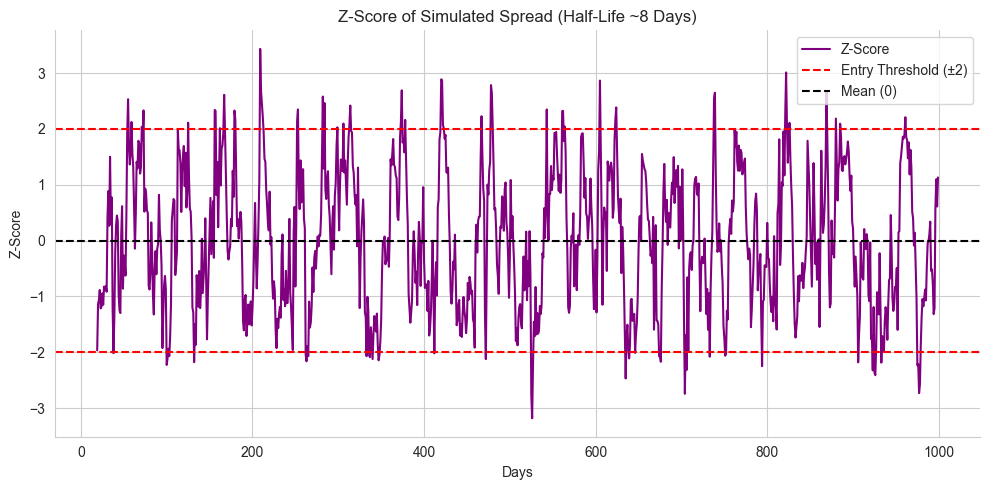

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style for cleaner visuals
sns.set_style('whitegrid')

rolling_window = 2 * hl
z_score = spread_series.sub(spread_series.rolling(window=rolling_window).mean()).div(spread_series.rolling(window=rolling_window).std())
plt.figure(figsize=(10, 5))
plt.plot(z_score.index, z_score, label='Z-Score', color='purple')
plt.axhline(y=2, color='red', linestyle='--', label='Entry Threshold (±2)')
plt.axhline(y=-2, color='red', linestyle='--')
plt.axhline(y=0, color='black', linestyle='--', label='Mean (0)')
plt.title('Z-Score of Simulated Spread (Half-Life ~8 Days)')
plt.xlabel('Days')
plt.ylabel('Z-Score')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()